Importing setup files

In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter

Load the core datasets

In [2]:
train_df = pd.read_csv("train.csv")
validation_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (2700, 2)
Validation shape: (338, 2)
Test shape: (338, 2)


,Question,Answer
0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...
1,What strategies can be employed to address the...,Strategies to address stigma and discriminatio...
2,What role do community events or festivals pla...,Community events or festivals provide opportun...
3,How can blood donation centers collaborate wit...,Blood donation centers can partner with transp...
4,How do blood donation centers ensure the quali...,Blood donation centers ensure the quality and ...


Final cleanup and normalization

In [3]:
def normalize_text(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

for df in [train_df, validation_df, test_df]:
    df["Question"] = df["Question"].apply(normalize_text)
    df["Answer"] = df["Answer"].apply(normalize_text)

print("Text normalization complete.")

Text normalization complete.


Removing any accidental duplicates inside each split

In [4]:
train_df = train_df.drop_duplicates(subset=["Question", "Answer"]).reset_index(drop=True)
validation_df = validation_df.drop_duplicates(subset=["Question", "Answer"]).reset_index(drop=True)
test_df = test_df.drop_duplicates(subset=["Question", "Answer"]).reset_index(drop=True)

print("Train shape after dedup:", train_df.shape)
print("Validation shape after dedup:", validation_df.shape)
print("Test shape after dedup:", test_df.shape)

Train shape after dedup: (2700, 2)
Validation shape after dedup: (338, 2)
Test shape after dedup: (338, 2)


Creating primary anchor–positive pairs

In [5]:
phase6_pairs = train_df.rename(columns={
    "Question": "anchor",
    "Answer": "positive"
})[["anchor", "positive"]].copy()

print("Primary anchor-positive pairs:", phase6_pairs.shape)
phase6_pairs.head()

Primary anchor-positive pairs: (2700, 2)


,anchor,positive
0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...
1,What strategies can be employed to address the...,Strategies to address stigma and discriminatio...
2,What role do community events or festivals pla...,Community events or festivals provide opportun...
3,How can blood donation centers collaborate wit...,Blood donation centers can partner with transp...
4,How do blood donation centers ensure the quali...,Blood donation centers ensure the quality and ...


Creating a symmetric training view

In [6]:
phase6_pairs["pair_type"] = "question_to_answer"

print(phase6_pairs["pair_type"].value_counts())
phase6_pairs.head()

pair_type
question_to_answer    2700
Name: count, dtype: int64


,anchor,positive,pair_type
0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...,question_to_answer
1,What strategies can be employed to address the...,Strategies to address stigma and discriminatio...,question_to_answer
2,What role do community events or festivals pla...,Community events or festivals provide opportun...,question_to_answer
3,How can blood donation centers collaborate wit...,Blood donation centers can partner with transp...,question_to_answer
4,How do blood donation centers ensure the quali...,Blood donation centers ensure the quality and ...,question_to_answer


Creating a retrieval corpus for hard-negative mining

In [7]:
question_corpus = pd.DataFrame({
    "text": train_df["Question"].tolist(),
    "text_type": "question"
})

answer_corpus = pd.DataFrame({
    "text": train_df["Answer"].tolist(),
    "text_type": "answer"
})

retrieval_corpus = pd.concat([question_corpus, answer_corpus], ignore_index=True)
retrieval_corpus = retrieval_corpus.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Retrieval corpus size:", retrieval_corpus.shape)
retrieval_corpus.head()

Retrieval corpus size: (5400, 2)


,text,text_type
0,How can blood donation centers collaborate wit...,question
1,What strategies can be employed to address the...,question
2,What role do community events or festivals pla...,question
3,How can blood donation centers collaborate wit...,question
4,How do blood donation centers ensure the quali...,question


Creating query dataset for future hard-negative mining

In [8]:
phase6_queries = pd.DataFrame({
    "query_id": range(len(train_df)),
    "query": train_df["Question"]
})

print("Phase 6 query set shape:", phase6_queries.shape)
phase6_queries.head()

Phase 6 query set shape: (2700, 2)


,query_id,query
0,0,How can blood donation centers collaborate wit...
1,1,What strategies can be employed to address the...
2,2,What role do community events or festivals pla...
3,3,How can blood donation centers collaborate wit...
4,4,How do blood donation centers ensure the quali...


Creating gold positives table

In [9]:
phase6_gold = pd.DataFrame({
    "query_id": range(len(train_df)),
    "query": train_df["Question"],
    "positive": train_df["Answer"]
})

print("Gold positive mapping shape:", phase6_gold.shape)
phase6_gold.head()

Gold positive mapping shape: (2700, 3)


,query_id,query,positive
0,0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...
1,1,What strategies can be employed to address the...,Strategies to address stigma and discriminatio...
2,2,What role do community events or festivals pla...,Community events or festivals provide opportun...
3,3,How can blood donation centers collaborate wit...,Blood donation centers can partner with transp...
4,4,How do blood donation centers ensure the quali...,Blood donation centers ensure the quality and ...


Adding simple topic hints 

In [10]:
def assign_topic(question):
    q = question.lower()
    if any(word in q for word in ["eligible", "eligibility", "can i donate", "allowed", "qualify"]):
        return "Eligibility"
    elif any(word in q for word in ["malaria", "hiv", "hepatitis", "infection", "disease", "sick", "cold", "flu"]):
        return "Disease/Illness"
    elif any(word in q for word in ["medicine", "medication", "drug", "antibiotic", "tablets"]):
        return "Medication"
    elif any(word in q for word in ["blood type", "o-", "o+", "a+", "a-", "b+", "ab", "rhesus"]):
        return "Blood Type"
    elif any(word in q for word in ["center", "location", "where", "place", "clinic", "hospital"]):
        return "Donation Center"
    elif any(word in q for word in ["wait", "how long", "deferral", "after", "months", "weeks", "days"]):
        return "Deferral Period"
    elif any(word in q for word in ["campaign", "event", "drive", "awareness"]):
        return "Campaign/Event"
    elif any(word in q for word in ["history", "before", "last donated", "again", "previous donation"]):
        return "Donor History"
    else:
        return "Other"

phase6_gold["topic"] = phase6_gold["query"].apply(assign_topic)

print(phase6_gold["topic"].value_counts())

topic
Other              1067
Blood Type          634
Donation Center     440
Campaign/Event      221
Disease/Illness     183
Eligibility          50
Medication           38
Deferral Period      34
Donor History        33
Name: count, dtype: int64


Inspecting topic distribution

<Axes: title={'center': 'Phase 6 Query Topic Distribution'}, xlabel='topic'>

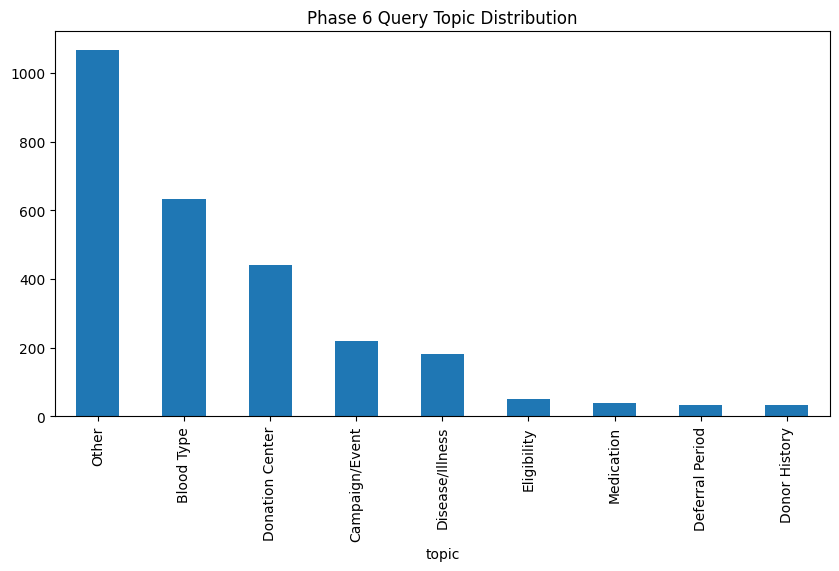

In [11]:
phase6_gold["topic"].value_counts().plot(kind="bar", figsize=(10,5), title="Phase 6 Query Topic Distribution")

Saving the fine-tuning design artifacts

In [12]:
phase6_pairs.to_csv("phase6_anchor_positive_pairs.csv", index=False)
phase6_queries.to_csv("phase6_queries.csv", index=False)
phase6_gold.to_csv("phase6_gold_positive_map.csv", index=False)
retrieval_corpus.to_csv("phase6_retrieval_corpus.csv", index=False)

print("Saved Phase 6 datasets:")
print("- phase6_anchor_positive_pairs.csv")
print("- phase6_queries.csv")
print("- phase6_gold_positive_map.csv")
print("- phase6_retrieval_corpus.csv")

Saved Phase 6 datasets:
- phase6_anchor_positive_pairs.csv
- phase6_queries.csv
- phase6_gold_positive_map.csv
- phase6_retrieval_corpus.csv


Creating a fine-tuned design summary table

In [13]:
phase6_summary = {
    "Training Q&A rows used": len(train_df),
    "Anchor-positive pairs created": len(phase6_pairs),
    "Unique retrieval corpus entries": len(retrieval_corpus),
    "Unique query topics": phase6_gold["topic"].nunique()
}

phase6_summary_df = pd.DataFrame(list(phase6_summary.items()), columns=["Metric", "Value"])
phase6_summary_df

,Metric,Value
0,Training Q&A rows used,2700
1,Anchor-positive pairs created,2700
2,Unique retrieval corpus entries,5400
3,Unique query topics,9


Spot-checking examples

In [14]:
phase6_pairs.sample(10, random_state=42)

,anchor,positive,pair_type
1339,How can appointment scheduling systems be cust...,Customization options include appointment slot...,question_to_answer
1222,What strategies can blood drive hosts employ t...,Blood drive hosts can employ strategies such a...,question_to_answer
1106,Question 18 How can digital platforms and virt...,"Utilizing virtual blood donation platforms, ho...",question_to_answer
812,How do perceptions of donation convenience and...,Perceptions of donation convenience and access...,question_to_answer
1231,What measures can be implemented to address do...,Measures may include expanding donor eligibili...,question_to_answer
565,How does the program foster a sense of communi...,The program fosters a sense of community and b...,question_to_answer
845,How do blood donation centers ensure the equit...,Blood donation centers ensure the equitable re...,question_to_answer
1004,How can blood donation centers personalize app...,Blood donation centers can personalize appoint...,question_to_answer
2283,What strategies can blood donation centers use...,Blood donation centers can use strategies to r...,question_to_answer
700,What strategies can blood donation centers use...,Blood donation centers can use strategies to e...,question_to_answer
